**Authors**: Firas Abouzahr (Northwestern), Sara Sussman (Fermilab)

# Electrostatic simulations for superconducting circuits

## What are electrostatic simulations?

Electrostatic simulations solve for the electric potential (V) and electric field (\mathbf{E}) throughout a structure. This is governed by Poisson's equation:

<center>$\nabla \cdot (\epsilon \nabla V) = -\rho$</center>

where $\epsilon$ is the permittivity and $\rho$ is the charge density.

Similar to how eigenmode simulations solve for the electromagnetic modes of a structure, electrostatic simulations solve for the electric potential and field distribution throughout a device. More accurately, Palace solves the *discretized* version of Poisson's equation rather than the continuous form shown above.


## Why electrostatic simulations?
Electrostatic simulations compute quantities such as capacitance matrices, electric-field participation ratios, and stored electric energy. 

For superconducting circuits, capacitances from electrostatic simulations can be used to quantify circuit couplings (e.g., intentional or parasitic) and determine the total effective capacitance of the qubit, which can then be used for lumped oscillator modeling (LOM) to extract the qubit Hamiltonian parameters, $f_q$ and $\alpha$.

# Electrostatic simulation and LOM analysis of a grounded transmon

## transmon design

In this tutorial, we use the transmon-qubit design from the 

In [2]:
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import Dict, Headings
from qiskit_metal import MetalGUI

from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

from SQDMetal.Comps.Xmon import Xmon
from SQDMetal.Comps.Junctions import JunctionDolanPinStretch
from SQDMetal.Comps.Capacitors import CapacitorProngPin
from SQDMetal.Utilities.Materials import MaterialInterface

In [3]:
design = designs.DesignPlanar({}, overwrite_enabled=True)
design.delete_all_components()
gui = MetalGUI(design)

um = 1e-3 # default units of Quantum Metal are in mm, so we get um by multiplying by 1e-3

# Set up chip dimensions 
design.chips.main.size.size_x = '3.5mm'
design.chips.main.size.size_y = '3mm'
design.chips.main.size.size_z = '-280um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Resonator and feedline gap width (W) and center conductor width (S) 
design.variables['cpw_width'] = '8 um' #S
design.variables['cpw_gap'] = '4 um' #W 
# Lets create the qubit with a junction and a claw

## Qubit
xmon = Xmon(design, 'xmon', options=Dict(pos_x = '0mm', pos_y='-1.6',
                                    vBar_width='50um', hBar_width='50um', vBar_gap=f'{50}um', hBar_gap=f'{50}um',
                                    cross_width=f'{320}um', cross_height=f'{320}um',
                                    gap_up='40um', gap_left='40um', gap_right='40um', gap_down='40um'))

# # Claw
CapacitorProngPin(design, 'claw', options=Dict(pin_inputs=Dict(start_pin=Dict(component=f'xmon',pin='up')),
                                                prong_width='10um', prong_length='20um', pin_gap_side='10um',
                                                gap_side='20um', pad_thickness='20um',
                                                gap_front='20um', gap_back='20um', trace_width='10um'))

# rebuild the GUI
gui.rebuild()
gui.autoscale()

### <u>Why don't we model the junctions for electrostatics?</u>

Electrostatic simulations only capture the capacitive properties of a device and are used to extract quantities such as capacitance matrices and charging energies. Since a Josephson junction contributes a nonlinear inductance rather than a significant capacitance, it has little impact on the electrostatic solution and is typically omitted. Its effect is instead incorporated later through the Josephson energy, $E_J$, when constructing the circuit Hamiltonian with LOM.

# Mesh Quantum Metal design with pyPalace (Gmsh backend)

In Palace, mesh attributes provide the labels used to specify entries in `config['Domains']` (volume regions or related postprocessing) and `config['Boundaries']` (surface regions where we apply boundary conditions or related postprocessing).

pyPalace leaves it up to the user to define which Quantum Metal surfaces we want to give mesh attributes for full flexibility. Volumes (substrate & air box), the far field, and the ground plane are automatically assigned mesh attributes. Let's take a look at our Quantum Metal design surfaces table:

In [4]:
from pypalace import mesh

In [5]:
surface_table = mesh.get_quantum_metal_surfaces(design)
surface_table

,component_id,component_name,name,subtract
0,1,xmon,cross,False
1,1,xmon,gap,True
2,2,claw,pad,False
3,2,claw,padGap,True


Polygons with `subtract == True` are the designs' metal (superconducting thin-film) components, while polygons with `subtract == False` are etched regions. We will want to give all metal components some boundary condition, so we need to give all of these mesh attributes. 

In [6]:
# each dictionary component has entry component ID, name, mesh attribute ID we want to assign it
attributes = {}

# this loop is simply assigning every metal component in our design a mesh attribute
mesh_num = 1
for row in range(len(surface_table)):
    this_component = surface_table.iloc[row]
    if this_component["subtract"] == False:
        name = this_component["name"]
        comp_id = this_component["component_id"]
        attributes[(comp_id,name)] = mesh_num
        mesh_num += 1 # cannot repeat mesh IDs or Palace will fail

attributes # each dictionary entry follows: (<component ID number>, <surface name>): <mesh attribute number> 

{(1, 'cross'): 1, (2, 'pad'): 2}

## Mesh the design

now that we have defined a dictionary for the Quantum Metal surfaces we want to give boundary conditions, we can actually mesh our design:

In [7]:
mesh_dir = "mesh/"
meshfile = "electrostatic_lom.msh"
path_to_mesh = mesh_dir + meshfile

## mesh the design --> returns pandas.dataframe of labeled mesh attributes ##
## look at readthedocs, mesh_Quantum_Metal_design has a lot of flexibility to control surface mesh size, volume mesh size, substrate size, etc ## 
attributes_table = mesh.mesh_Quantum_Metal_design(design,
                                                  output_mesh=path_to_mesh,
                                                  Attributes=attributes);

Info    : Meshing 1D...nts                                                                                                                
Info    : [  0%] Meshing curve 49 (Line)
Info    : [ 10%] Meshing curve 50 (Line)
Info    : [ 10%] Meshing curve 51 (Line)
Info    : [ 10%] Meshing curve 52 (Line)
Info    : [ 10%] Meshing curve 53 (Line)
Info    : [ 10%] Meshing curve 54 (Line)
Info    : [ 10%] Meshing curve 55 (Line)
Info    : [ 20%] Meshing curve 56 (Line)
Info    : [ 20%] Meshing curve 57 (Line)
Info    : [ 20%] Meshing curve 58 (Line)
Info    : [ 20%] Meshing curve 59 (Line)
Info    : [ 20%] Meshing curve 60 (Line)
Info    : [ 20%] Meshing curve 61 (Line)
Info    : [ 30%] Meshing curve 62 (Line)
Info    : [ 30%] Meshing curve 63 (Line)
Info    : [ 30%] Meshing curve 64 (Line)
Info    : [ 30%] Meshing curve 65 (Line)
Info    : [ 30%] Meshing curve 66 (Line)
Info    : [ 30%] Meshing curve 67 (Line)
Info    : [ 30%] Meshing curve 68 (Line)
Info    : [ 40%] Meshing curve 69 (Line)


`pypalace.mesh.mesh_Quantum_Metal_design` returns an ordered dataframe of the mesh components. We will use these to build our Palace configuration file. Notice this function automatically makes a ground plane, an air box, a substrate box, and the far field. 

In [8]:
attributes_table

,Name,ID,Type
0,1__cross,1,Surface
1,2__pad,2,Surface
4,substrate,3,Volume
5,air,4,Volume
2,ground_plane,5,Surface
3,far_field,6,Surface


# Build Palace configuration file with pyPalace

pyPalace follows the Palace configuration schema one-to-one. In this sense, the pyPalace configuration building using `pypalace.Config` and `pypalace.builder` follows directly from the [Palace config documentation](https://awslabs.github.io/palace/stable/config/config/).

In [9]:
from pypalace import Config
from pypalace.builder import Model, Domains, Boundaries, Solver  # these match one-to-one with Palace config syntax

In [10]:
''' choose path & name for Palace configuration file we will build below '''
config_dir = "config/"
path_to_config = config_dir + "electrostatic_lom.json"

## Initialize pyPalace Config object:

In [11]:
electrostatic_config = Config(path_to_config)

## Add `config['Problems']` and `config['Model']`

In [12]:
electrostatic_config.add_Problem(Type="Electrostatic",
                             Output="electrostatic_output")

# don't use here but this is how we could add adaptive mesh refinement
#AMR = Model.Refinement(Tol = 1e-6,MaxIts = 3)

# define config['Model'] block
electrostatic_config.add_Model(Mesh = path_to_mesh, # point to our meshfile
                    L0 = 1e-6,# mesh units relative to meters
                    #Refinement=AMR
                    ) 

## Add `config['Domains']`

Used to define properties and postprocessing for meshed volumes.

In [13]:
# from the attribute table above:
substrate_id = 3
airbox_id = 4

# define materials
silicon = Domains.Material(Attributes = [substrate_id], # attributes to give the properties below to:
                                     Permeability=1.0, # magnetic permeability
                                     Permittivity=11.45, # electric permittivity
                                     LossTan=1e-07) # bulk loss tangent

airbox = Domains.Material([airbox_id],1.0,1.0,0.0)

# will not use this here but an example of adding domain postprocessing:


materials = [silicon,airbox] # material list for input into add_Domains()
electrostatic_config.add_Domains(Materials = materials) # add materials to our configuration file

## Add `config['Boundaries']`

Used to define boundary conditions and postprocessing for meshed surfaces.

### Some notes on boundary conditions for electrostatic simulations of superconducting circuits
### <u>What are terminals?</u>

Terminals identify the conductors that should be included in the capacitance extraction. Palace excites each terminal one-by-one and computes the resulting charge distribution, allowing the mutual capacitances between conductors to be calculated. In superconducting circuits, terminals typically correspond to qubit pads, couplers, resonators, or other electrically distinct metal structures.

### <u>Why don't electrostatic simulations use PEC boundaries?</u>

In electrostatic simulations, the conductors of interest are already defined as terminals. The solver then computes the charge distribution on these conductors to determine their mutual capacitances. Applying a PEC boundary condition would instead fix a conductor as an equipotential surface outside of the capacitance extraction procedure, preventing Palace from treating it as an independent conductor in the capacitance matrix. *The ground plane and far field are given grounded boundary conditions*

In [14]:
attributes_table

,Name,ID,Type
0,1__cross,1,Surface
1,2__pad,2,Surface
4,substrate,3,Volume
5,air,4,Volume
2,ground_plane,5,Surface
3,far_field,6,Surface


In [15]:
# using attributes_table returned from meshing:
# mesh IDs for metals / PECs 
cross_id = 1
claw_id = 2
ground_id = 5
farfield_id = 6

# assign terminals to each metal we want in the capacitance matrix
qubit_terminal = Boundaries.Terminal(Index=1,Attributes=[cross_id])
claw_terminal = Boundaries.Terminal(Index=2,Attributes=[claw_id])

# assign ground plane and far field as grounds
grounds = Boundaries.Ground(Attributes=[ground_id,farfield_id])

# to get the capacitance matrix out we need to define 


# add Boundary conditions and boundary postprocessing to our configuration file
BCs = [qubit_terminal,claw_terminal,grounds] # boundary condition list for input into add_Boundaries()
electrostatic_config.add_Boundaries(BCs=BCs)

## Add `config['Solver']`

Used to define the numerical parameters controlling the simulation.

Below, we intentionally use relatively coarse solver settings to reduce compute time for the purposes of this tutorial. For higher-fidelity simulations, more stringent settings may be appropriate:

| Electrostatic Parameter | Value |
| :---: | :---: |
| Tol | 1e-10 |
| MaxIts | 100 |

| Linear Solver Parameter | Value |
| :---: | :---: |
| Tol | 1e-12 |
| MaxIts | 500 |

In addition to the solver settings below, the finite element basis order can significantly impact simulation accuracy.

> **Note:** Refined simulation parameters and higher-order basis orders will generally improve solution accuracy and convergence, but may significantly increase computational cost.

In [16]:
## electrostatic parameters
electrostatic_params =  Solver.Electrostatic(Save=2)

## linear solver parameters
Linear_params = Solver.Linear(Type="BoomerAMG",
                              KSPType = "CG",
                              Tol = 1e-6, # make more stringent for better results
                              MaxIts = 25) 
                              
electrostatic_config.add_Solver(Simulation=electrostatic_params,
                                Order= 1, # first order solver
                                Linear=Linear_params)

## Save our configuration file 

In [17]:
electrostatic_config.save_config(check_validity=True)
electrostatic_config.print_config()

{
  "Problem": {
    "Type": "Electrostatic",
    "Verbose": 2,
    "Output": "electrostatic_output"
  },
  "Model": {
    "Mesh": "mesh/electrostatic_lom.msh",
    "L0": 1e-06
  },
  "Domains": {
    "Materials": [
      {
        "Attributes": [
          3
        ],
        "Permeability": 1.0,
        "Permittivity": 11.45,
        "LossTan": 1e-07
      },
      {
        "Attributes": [
          4
        ],
        "Permeability": 1.0,
        "Permittivity": 1.0,
        "LossTan": 0.0
      }
    ]
  },
  "Boundaries": {
    "Ground": {
      "Attributes": [
        5,
        6
      ]
    },
    "Terminal": [
      {
        "Index": 1,
        "Attributes": [
          1
        ]
      },
      {
        "Index": 2,
        "Attributes": [
          2
        ]
      }
    ]
  },
  "Solver": {
    "Order": 1,
    "Device": "CPU",
    "Electrostatic": {
      "Save": 2
    },
    "Linear": {
      "Type": "BoomerAMG",
      "KSPType": "CG",
      "Tol": 1e-06,
      "MaxI

## Run the electrostatic simulation of our transmon

In [18]:
from pypalace import Simulation # used to run simulations and extract simulation results 
from pypalace.palace_env import get_palace_executable  # auto-find path_to_palace 
from qdw_workshop.palace import install_pypalace_runner, palace_cpu_count

install_pypalace_runner()

In [19]:
path_to_palace = get_palace_executable() # only works if you added palace to your path, if not use line below
# path_to_palace = /path/to/palace-

### Initialize our simulation object

In [20]:
electrostatic_simulation = Simulation(electrostatic_config,path_to_palace)

### Run the simulation

In [21]:
mpi_processes = palace_cpu_count(4)
electrostatic_simulation.run(n=mpi_processes)


_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (electrostatic_output)
Git changeset ID: v0.13.0-509-g360de9ab
Running with 4 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 12 elements in 1 iterations of local bisection for under-resolved interior boundaries
Added 1242 duplicate vertices for interior boundaries in the mesh
Added 3017 duplicate boundary elements for interior boundaries in the mesh
Added 4067 boundary elements for material interfaces to the mesh
Finished partitioning mesh into 4 subdomains

Characteristic length and time scales:
 L₀ = 1.406e-03 m, t₀ = 4.690e-03 ns

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-7.000e-04, -2.300e-03, -5.000e-04) m
 (Xmax, 

# Visualize the electric potential, $V$

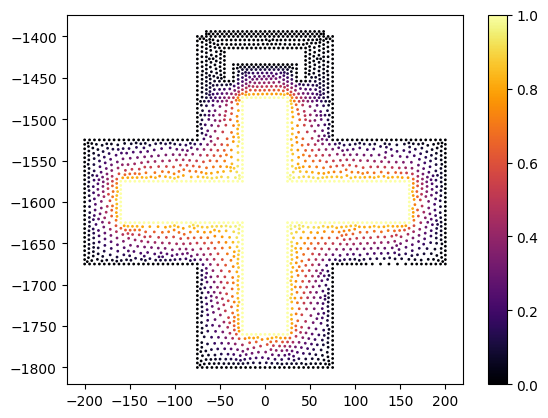

In [22]:
%matplotlib inline
electrostatic_simulation.plot_field(field="V",index=1) # plot magnitude of electric field [V/m]

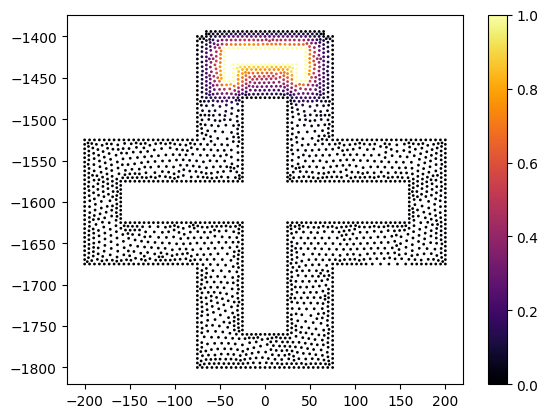

In [23]:
electrostatic_simulation.plot_field(field="V",index=2) # plot magnitude of electric field [V/m]

the above field distributions confirm that the first mode corresponds to our qubit and the third mode corresponds to the resonator. The second looks deceivingly like a resonator mode as well but the field shape implies it's a spurious mode. This would probably be removed with the addition of airbridges. 

# Extract simulation results 

The main result of an electrostatic simulation is the Maxwell capacitance matrix.

### <u>What is the Maxwell capacitance matrix?</u>

The Maxwell capacitance matrix describes how charge is distributed among a set of conductors. Its diagonal elements represent the self-capacitance of each conductor, while its off-diagonal elements represent the mutual capacitive coupling between conductors. This matrix forms the foundation for extracting circuit parameters such as the qubit charging energy ($E_C$) and qubit-resonator coupling strengths, along with parasitic couplings if relevant.

For this qubit + claw system we expect:

$$
\mathbf{C} = \begin{pmatrix}
C_{qq} & C_{qc} & C_{qg} \\
C_{cq} & C_{cc} & C_{cg} \\
C_{gq} & C_{gc} & C_{gg}
\end{pmatrix}
$$

where $C_{qq}$ is the qubit self-capacitance, $C_{cc}$ is the coupling claw self-capacitance, $C_{gg}$ is the ground self-capacitance, and the off-diagonal elements $C_{qc}=C_{cq}$, $C_{qg}=C_{gq}$, and $C_{cg}=C_{gc}$ represent the mutual capacitances between conductors.

In [24]:
# extract capacitance matrix 
capacitance_matrix = electrostatic_simulation.get_capacitance_matrix()

# rename nicely 
elements = ["qubit","claw","ground"]
capacitance_matrix.columns = elements
capacitance_matrix.index = elements
capacitance_matrix

,qubit,claw,ground
qubit,9.739613e-14,-4.946368e-15,-9.244976e-14
claw,-4.946368e-15,2.698940e-14,-2.204303e-14
ground,-9.244976e-14,-2.204303e-14,0.000000e+00


# LOM Analysis

LOM approximates a superconducting circuit as a network of lumped circuit elements (a superconducting quantum circuit). Using capacitances extracted from electrostatic simulations and Josephson junction parameters, LOM enables calculation of circuit-QED Hamiltonian parameters such as the qubit frequency and anharmonicity.

pyPalace uses [scQubits](https://scqubits.readthedocs.io/en/latest/) for LOM analysis.

> For a more in-depth look at quantum analysis techniques, check out the **EM Quantum Analysis Techniques** workshop led by Alp Sipahigil (if you are attending QDW).


In [25]:
from pypalace.analysis import LOM

## Calculate $C_\Sigma$

For a ground-transmon such as the xmon design we have here, the shunt capacitance ($C_s$) is given by:

$$C_s = |C_{qg}| + |C_{qc}| = C_{qq}$$

And $C_\Sigma$ is given by: 

$$C_\Sigma = C_s + C_J \approx C_{s}$$

Also choose an $L_J$ (equivalently $E_J$) by hand. We will take $L_J = 9.09 \text{ nH}$ following from the [`quantum-device-design`](../quantum-device-design/) workshop.

In [26]:
C_Sigma = LOM.calculate_C_Sigma(capacitance_matrix,topology="grounded")
LJ = 9.09*1e-09 # nH

In [27]:
transmon_parameters = LOM.get_qubit_Hamiltonian_parameters(C_Sigma,LJ)
fq = transmon_parameters['frequency_GHz']*1e9
alpha = transmon_parameters['anharmonicity_MHz']*1e6
transmon_parameters

{'frequency_GHz': 5.141821404078801, 'anharmonicity_MHz': -219.0764320419421}

## Full transmon–resonator Hamiltonian parameters from the capacitance matrix

Using the results of LOM ($f_q$ and $\alpha$) combined with some analytic equations, we can also calculate transmon-resonator coupled system parameters. 

Based on the [eigenmode + EPR demo](./eigenmode_EPR.ipynb), let's take the resonator frequency to be $f_r = 6.79 \text{ GHz}$

> **Note:** This notebook simulates a grounded xmon transmon in isolation. The [eigenmode + EPR demo](./eigenmode_EPR.ipynb) uses the full transmon–resonator layout from quantum-device-design. We import $f_r$ from that demo for an approximate cross-check of coupled-system parameters.


In [28]:
fr = 6.79*1e9 #GHz
Cr = LOM.calculate_C_r(f_r=fr,
                       m=2 # m=2 for quarter wavelength resonator
                       )

g = LOM.calculate_coupling_strength(capacitance_matrix, LJ, fr, Cr, topology="grounded")
chi = LOM.calculate_dispersive_shift(fq, fr, alpha, g)

We now have all the desired Hamiltonian parameters (besides $\kappa$) for the full transmon-resonator system.

In [29]:
print("Hamiltonian parameters:")
print("=======================")
print("\nQubit parameters:")
print("-----------------------")
print(f"f_q = {fq/1e9:.2f} GHz")
print(f"alpha = {alpha/1e6:.2f} MHz")
print("\nResonator parameters:")
print("-----------------------")
print(f"f_r = {fr/1e9:.2f} GHz")
print("\nCoupled parameters:")
print("-----------------------")
print(f"chi = {chi/1e6:.2f} MHz")
print(f"g = {g/1e6:.2f} MHz")

Hamiltonian parameters:

Qubit parameters:
-----------------------
f_q = 5.14 GHz
alpha = -219.08 MHz

Resonator parameters:
-----------------------
f_r = 6.79 GHz

Coupled parameters:
-----------------------
chi = -0.45 MHz
g = 55.65 MHz


Nicely, we see that these Hamiltonian parameters are in close agreement (same order of magnitude) to our results from the [eigenmode + EPR demo](./eigenmode_EPR.ipynb). Both this simulation and the eigenmode simulation from last demo were done with very coarse meshing and low-fidelity simulation parameters. If we refined the meshing and bumped up the simulation parameters, we would expect to see even higher agreement.

# Next tutorial: driven resonator simulation

